

# Projet Deep Learning - Big Data MAPI3 2025


**Diallo Moussa**


In [ ]:
# Nous allons Commencer par télécharger et faire l'extraction du Dataset de l'images de paysages

!wget https://github.com/ml5js/ml5-data-and-models/raw/master/datasets/images/landscapes/landscapes_small.zip

!mkdir landscapes

!unzip landscapes_small.zip -d landscapes

!rm -r landscapes/__MACOSX

--2026-02-18 18:43:11--  https://github.com/ml5js/ml5-data-and-models/raw/master/datasets/images/landscapes/landscapes_small.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ml5js/ml5-data-and-models/master/datasets/images/landscapes/landscapes_small.zip [following]
--2026-02-18 18:43:11--  https://raw.githubusercontent.com/ml5js/ml5-data-and-models/master/datasets/images/landscapes/landscapes_small.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81935123 (78M) [application/zip]
Saving to: ‘landscapes_small.zip’

landscapes_small.zi 100%[===================>]  78.14M   393MB/s    in 0

In [ ]:
# Importation des bibliothèques nécessaires pour le deep learning et la visualisation

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
                                      BatchNormalization, Dropout, Flatten,
                                      Concatenate, UpSampling2D, GlobalAveragePooling2D)
from tensorflow import keras
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import time
import os

<font color='blue'>**Question 1) Séparer vos données en 2 : 80% apprentissage, 20% validation**</font>

In [ ]:
# 1) Préparation des données
dataset_dir = "landscapes"  # chemin vers le dossier des images

# Lister les classes
class_names = os.listdir(dataset_dir)
num_classes = len(class_names)
print(f"Les {num_classes} classes sont : {class_names}")

# Compter les images par classe
print("\nDistribution des images par classe :")
for name in class_names:
    class_path = os.path.join(dataset_dir, name)
    num_images = len(os.listdir(class_path))
    print(f"- Classe '{name}': {num_images} images")

Les 7 classes sont : ['field', 'lake', 'mountain', 'forest', 'ocean', 'road', 'city']

Distribution des images par classe :
- Classe 'field': 491 images
- Classe 'lake': 570 images
- Classe 'mountain': 677 images
- Classe 'forest': 680 images
- Classe 'ocean': 435 images
- Classe 'road': 595 images
- Classe 'city': 333 images


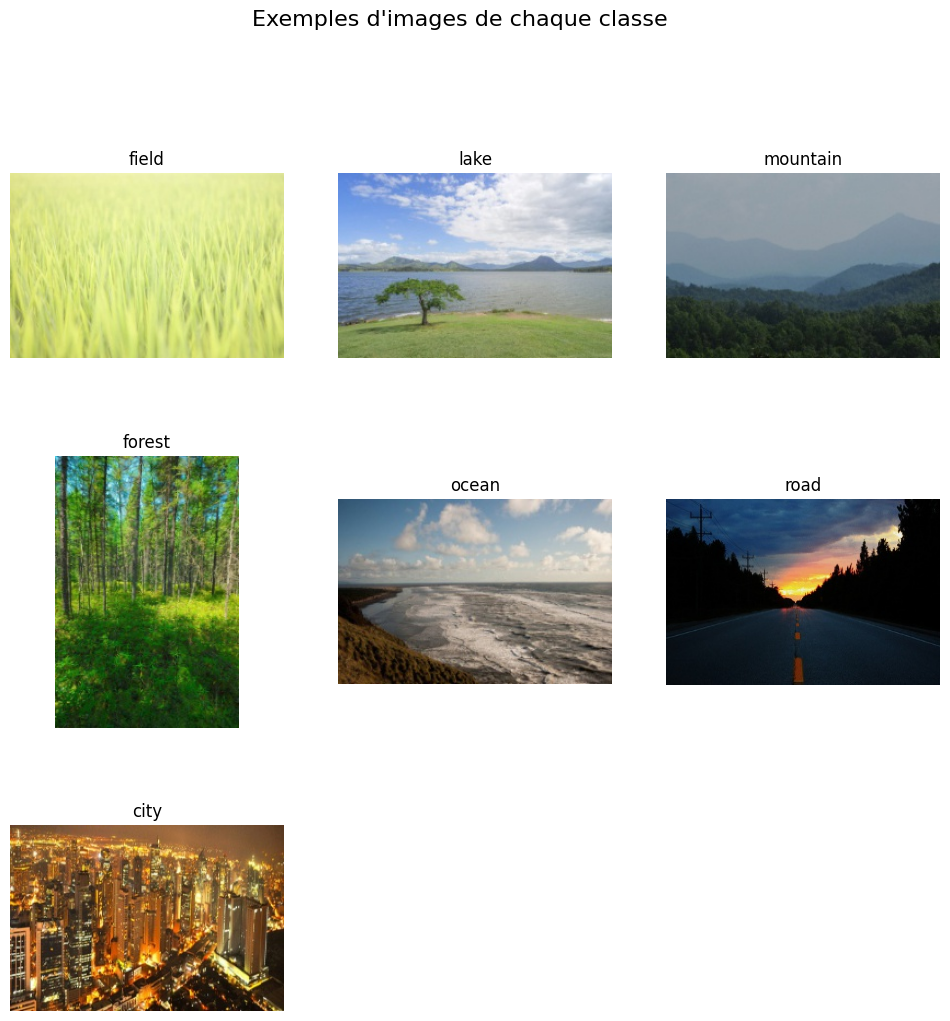

In [ ]:
plt.figure(figsize=(12, 12))
for i, class_name in enumerate(class_names):
    # Choisir une image au hasard dans le dossier de la classe
    class_path = os.path.join(dataset_dir, class_name)
    all_images = os.listdir(class_path)
    random_image_path = os.path.join(class_path, np.random.choice(all_images))

    # Afficher l'image
    ax = plt.subplot(3, 3, i + 1)
    img = tf.keras.utils.load_img(random_image_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Exemples d'images de chaque classe", fontsize=16)
plt.show()

In [ ]:
# ImageDataGenerator avec rescaling et split 80/20
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Jeu d'entraînement (80%)
train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',  # 80%
    shuffle=True
)

# Jeu de validation (20%)
val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # 20%
    shuffle=True
)


Found 3026 images belonging to 7 classes.
Found 755 images belonging to 7 classes.


<font color='blue'>**Question 2) Définir et entraîner un réseau de convolution simple**</font>

In [ ]:
# 2) Définition du réseau CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.2940 - loss: 1.7647 - val_accuracy: 0.5722 - val_loss: 1.1769
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.5430 - loss: 1.2387 - val_accuracy: 0.6450 - val_loss: 0.9782
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5837 - loss: 1.1207 - val_accuracy: 0.6834 - val_loss: 0.8961
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6297 - loss: 1.0239 - val_accuracy: 0.6570 - val_loss: 0.9758
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6512 - loss: 0.9574 - val_accuracy: 0.7338 - val_loss: 0.7230
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7284 - loss: 0.7793 - val_accuracy: 0.7589 - val_loss: 0.7122
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7548 - loss: 0.6897 - val_accuracy: 0.7695 - val_loss: 0.6623
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7987 - loss: 0.5752 - val_accuracy: 0.8172 - val_loss: 

In [ ]:
# Modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,916,631 (37.83 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,611,088 (25.22 MB)

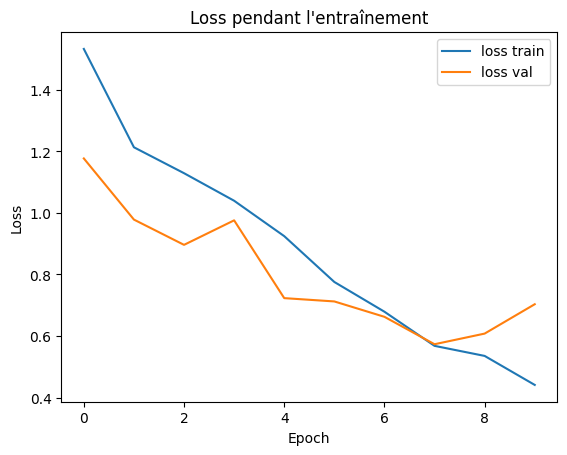

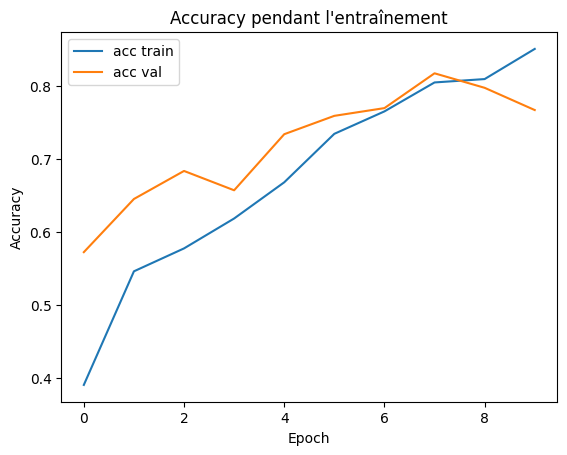

In [ ]:
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss val')
plt.title("Loss pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.plot(history.history['accuracy'], label='acc train')
plt.plot(history.history['val_accuracy'], label='acc val')
plt.title("Accuracy pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

<font color='blue'>**Question 3) Amélioration de la généralisation (Data Augmentation, Dropout)**</font>

In [ ]:
# 3) Data augmentation + dropout

# Data augmentation
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_aug = aug_datagen.flow_from_directory(dataset_dir, target_size=(128,128),
                                            batch_size=32, class_mode='categorical', subset='training')
val_aug = aug_datagen.flow_from_directory(dataset_dir, target_size=(128,128),
                                          batch_size=32, class_mode='categorical', subset='validation')

# CNN simple avec dropout
model_aug = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_aug = model_aug.fit(train_aug, validation_data=val_aug, epochs=10)


Found 3026 images belonging to 7 classes.
Found 755 images belonging to 7 classes.
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.3217 - loss: 1.9198 - val_accuracy: 0.5325 - val_loss: 1.1279
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.5330 - loss: 1.2390 - val_accuracy: 0.6477 - val_loss: 0.9852
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.5789 - loss: 1.1392 - val_accuracy: 0.6517 - val_loss: 0.9470
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 185ms/step - accuracy: 0.6038 - loss: 1.0817 - val_accuracy: 0.6768 - val_loss: 0.8821
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 198ms/step - accuracy: 0.6456 - loss: 0.9895 - val_accuracy: 0.6490 - val_loss: 0.9547
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.6221 - loss: 1.0295 - val_accuracy: 0.7073 - val_loss: 0.8552
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.6318 - loss: 1.0027 - val_accuracy: 0.6689 - val_loss: 0.8699
Epoch 8/10
95/

In [ ]:
model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,179,671 (84.61 MB)

 Trainable params: 7,393,223 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,786,448 (56.41 MB)

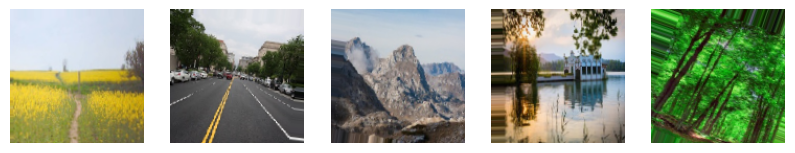

In [ ]:
# Affichage de quelques images augmentées
x_batch, y_batch = next(train_aug)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_batch[i])
    plt.axis('off')
plt.show()

Ces images montrent le résultat de la data augmentation :
elles sont légèrement tournées, décalées ou retournées horizontalement pour rendre le modèle plus robuste et mieux capable de généraliser sur de nouvelles images.


<font color='blue'>**Question 4) Transfer Learning avec réseau pré-entraîné**</font>

In [ ]:
# 4) Transfer Learning (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False

model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_tl = model_tl.fit(train_gen, validation_data=val_gen, epochs=10)




9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 49s 343ms/step - accuracy: 0.6990 - loss: 0.8593 - val_accuracy: 0.9404 - val_loss: 0.2026
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9163 - loss: 0.2577 - val_accuracy: 0.9430 - val_loss: 0.1847
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9447 - loss: 0.1600 - val_accuracy: 0.9510 - val_loss: 0.1947
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9631 - loss: 0.1401 - val_accuracy: 0.9536 - val_loss: 0.1665
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9673 - loss: 0.1065 - val_accuracy: 0.9510 - val_loss: 0.1858
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9684 - loss: 0.0920 - val_accuracy: 0.9523 - val_loss: 0.1925
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9737 - loss: 0.0861 - val_accuracy: 0.9497 - val_loss: 0.1910
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accurac

In [ ]:
model_tl.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,599 (10.50 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,744 (1.26 MB)

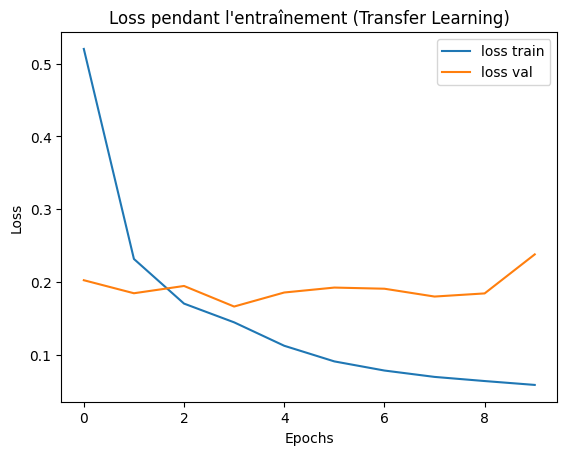

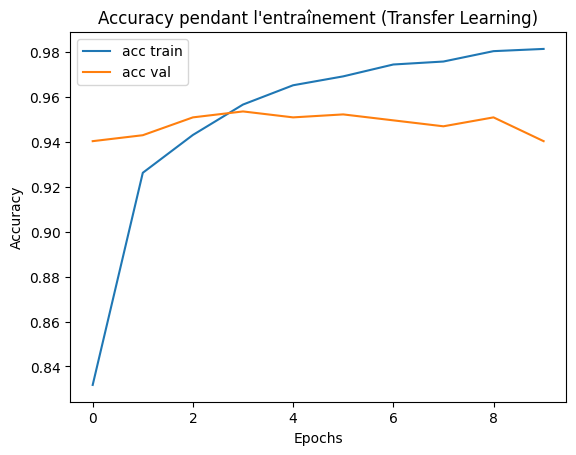

In [ ]:
# Tracé de la loss
plt.plot(history_tl.history['loss'], label='loss train')
plt.plot(history_tl.history['val_loss'], label='loss val')
plt.title("Loss pendant l'entraînement (Transfer Learning)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Tracé de l'accuracy
plt.plot(history_tl.history['accuracy'], label='acc train')
plt.plot(history_tl.history['val_accuracy'], label='acc val')
plt.title("Accuracy pendant l'entraînement (Transfer Learning)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


La loss diminue rapidement dès les premières epochs : le modèle apprend vite grâce aux poids pré-entraînés.

La loss de validation suit de près la loss d'entraînement :  le modèle généralise bien et n'overfit pas trop.

L'accuracy augmente progressivement pour l'entraînement et la validation :  le modèle devient précis sur les images vues et sur les nouvelles images.

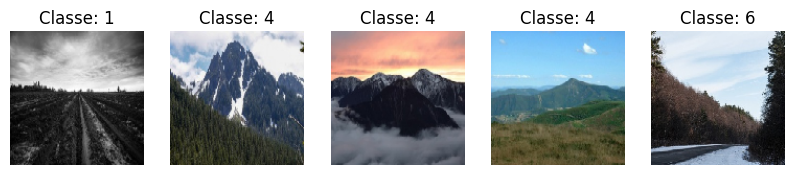

In [ ]:
# Affichage de quelques images avec leurs vraies classes
indices = np.random.choice(len(val_gen.filepaths), 5, replace=False)
plt.figure(figsize=(10,5))
for i, idx in enumerate(indices):
    img_path = val_gen.filepaths[idx]
    label = val_gen.classes[idx]
    img = load_img(img_path, target_size=(128,128))
    img = img_to_array(img) / 255.0
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Classe: {label}")
    plt.axis('off')
plt.show()

<font color='blue'>**Question 5) Comparer les résultats dans un tableau**</font>

In [ ]:
# Fonction pour récupérer les infos du modèle
def model_info(model, history):
    return {
        "Loss (val)": round(min(history.history['val_loss']), 4),
        "Accuracy (val)": round(max(history.history['val_accuracy']), 4),
        "Nb paramètres (total)": model.count_params(),
        "Nb paramètres (entraînables)": sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    }

# Construction du tableau
results = pd.DataFrame({
    "Modèle": ["CNN simple", "CNN + Augmentation", "Transfer Learning"],
    **pd.DataFrame([
        model_info(model, history),
        model_info(model_aug, history_aug),
        model_info(model_tl, history_tl)
    ])
})

results


,Modèle,Loss (val),Accuracy (val),Nb paramètres (total),Nb paramètres (entraînables)
0,CNN simple,0.5732,0.8172,3305543,3305543
1,CNN + Augmentation,0.7818,0.7272,7393223,7393223
2,Transfer Learning,0.1665,0.9536,2422855,164871


<font color='blue'>**Question 6)  Afficher quelques erreurs de prédiction**</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


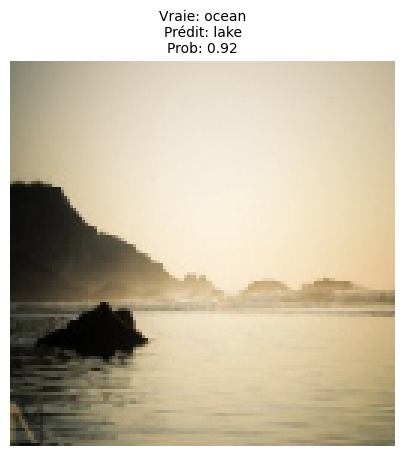

In [ ]:
# 6) Affichage de 10 erreurs variées avec noms des classes
# Mapping index  nom de classe
class_names = {v: k for k, v in train_gen.class_indices.items()}

# Batch de validation
x_val, y_val = next(val_gen)
preds = model_tl.predict(x_val)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(y_val, axis=1)

# Indices des erreurs
errors = np.where(pred_classes != true_classes)[0]

# Sélectionner jusqu'à 10 erreurs variées (différentes classes)
shown_classes = set()
selected_errors = []
for idx in errors:
    if true_classes[idx] not in shown_classes:
        selected_errors.append(idx)
        shown_classes.add(true_classes[idx])
    if len(selected_errors) >= 10:
        break

# Affichage des erreurs
plt.figure(figsize=(20,5))
for i, idx in enumerate(selected_errors):
    plt.subplot(1, len(selected_errors), i+1)
    plt.imshow(x_val[idx])
    plt.axis('off')
    plt.title(f"Vraie: {class_names[true_classes[idx]]}\n"
              f"Prédit: {class_names[pred_classes[idx]]}\n"
              f"Prob: {np.max(preds[idx]):.2f}", fontsize=10)
plt.show()


<font color='blue'>**Question 7)  t-SNE sur les features (quelques centaines d’images)**</font>

In [ ]:
max_samples = 300  # sous-échantillon pour t-SNE
X_imgs, y_true = [], []

val_gen.reset()  # remet le générateur à zéro
for x_batch, y_batch in val_gen:
    X_imgs.append(x_batch)
    y_true.append(np.argmax(y_batch, axis=1))
    if len(np.concatenate(y_true)) >= max_samples:
        break

X_imgs = np.concatenate(X_imgs)[:max_samples]
y_true = np.concatenate(y_true)[:max_samples]

print("Sous-ensemble:", X_imgs.shape, y_true.shape)

# Feature extractor : MobileNetV2
feature_extractor = tf.keras.Model(
    inputs=model_tl.layers[0].input,  # base_model
    outputs=model_tl.layers[0].output  # MobileNetV2 outputs
)

features = feature_extractor.predict(X_imgs, verbose=0)
# GlobalAveragePooling pour obtenir un vecteur par image
features = tf.reduce_mean(features, axis=(1,2)).numpy()
print("Features:", features.shape)

# PCA  réduit la dimension pour accélérer t-SNE
pca = PCA(n_components=min(50, features.shape[1]), random_state=42)
features_pca = pca.fit_transform(features)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
features_2d = tsne.fit_transform(features_pca)

# Mapping index nom de classe
idx_to_class = {v: k for k, v in val_gen.class_indices.items()}

Sous-ensemble: (300, 128, 128, 3) (300,)
Features: (300, 1280)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


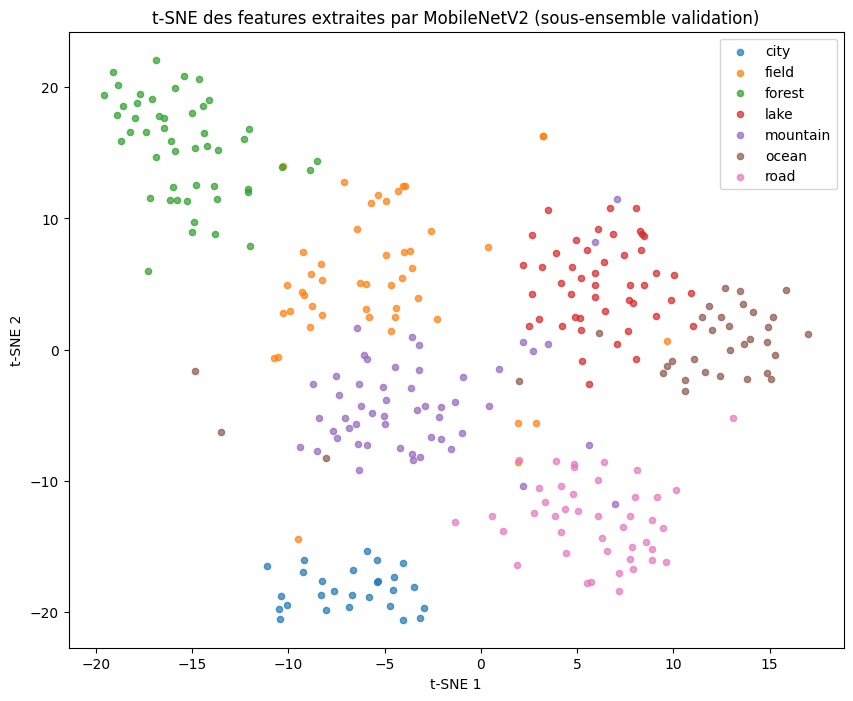

In [ ]:
# Affichage
plt.figure(figsize=(10, 8))
for c in np.unique(y_true):
    mask = (y_true == c)
    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=20,
        alpha=0.7,
        label=idx_to_class[c]
    )

plt.title("t-SNE des features extraites par MobileNetV2 (sous-ensemble validation)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()

Le t-SNE montre que les images de la même classe sont regroupées dans l’espace des features, ce qui signifie que le modèle extrait des caractéristiques discriminantes.

<font color='blue'>**Question 8)   k-NN pour trouver les images les plus proches**</font>

In [ ]:
# k-NN sur les features
knn = NearestNeighbors(n_neighbors=4, metric="euclidean")
knn.fit(features)

# Choisir une image requête au hasard
query_idx = random.randint(0, len(features) - 1)

distances, indices = knn.kneighbors(features[query_idx].reshape(1, -1))
indices = indices[0]
distances = distances[0]

print("Image requête index:", query_idx, "| Classe:", idx_to_class[y_true[query_idx]])
print("Indices voisins:", indices)
print("Distances:", np.round(distances, 3))

Image requête index: 272 | Classe: field
Indices voisins: [272 141 120  19]
Distances: [ 0.    22.579 22.677 23.021]


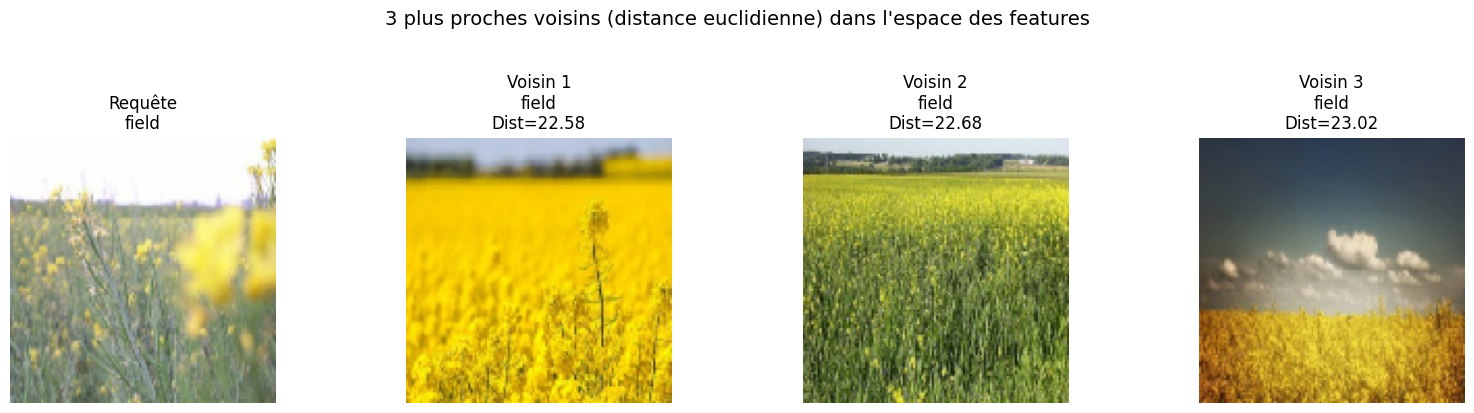

In [ ]:
# Affichage : requête + 3 plus proches voisins
plt.figure(figsize=(16, 4))  # plus large pour espacer
for i, (idx, dist) in enumerate(zip(indices, distances)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(X_imgs[idx])
    plt.axis("off")
    if i == 0:
        plt.title(f"Requête\n{idx_to_class[y_true[idx]]}", fontsize=12)
    else:
        plt.title(f"Voisin {i}\n{idx_to_class[y_true[idx]]}\nDist={dist:.2f}", fontsize=12)

# Ajustement pour éviter que le suptitle chevauche
plt.tight_layout(rect=[0, 0, 1, 0.85])  # réserve de l'espace en haut
plt.suptitle("3 plus proches voisins (distance euclidienne) dans l'espace des features", fontsize=14, y=1.02)
plt.show()
